In [2]:
import torch
import torch.nn as nn
from dataclasses import dataclass
import torch.nn.functional as F
import math

from ROPE import ROPE, apply_rotary_pos_emb

torch.random.manual_seed(42)

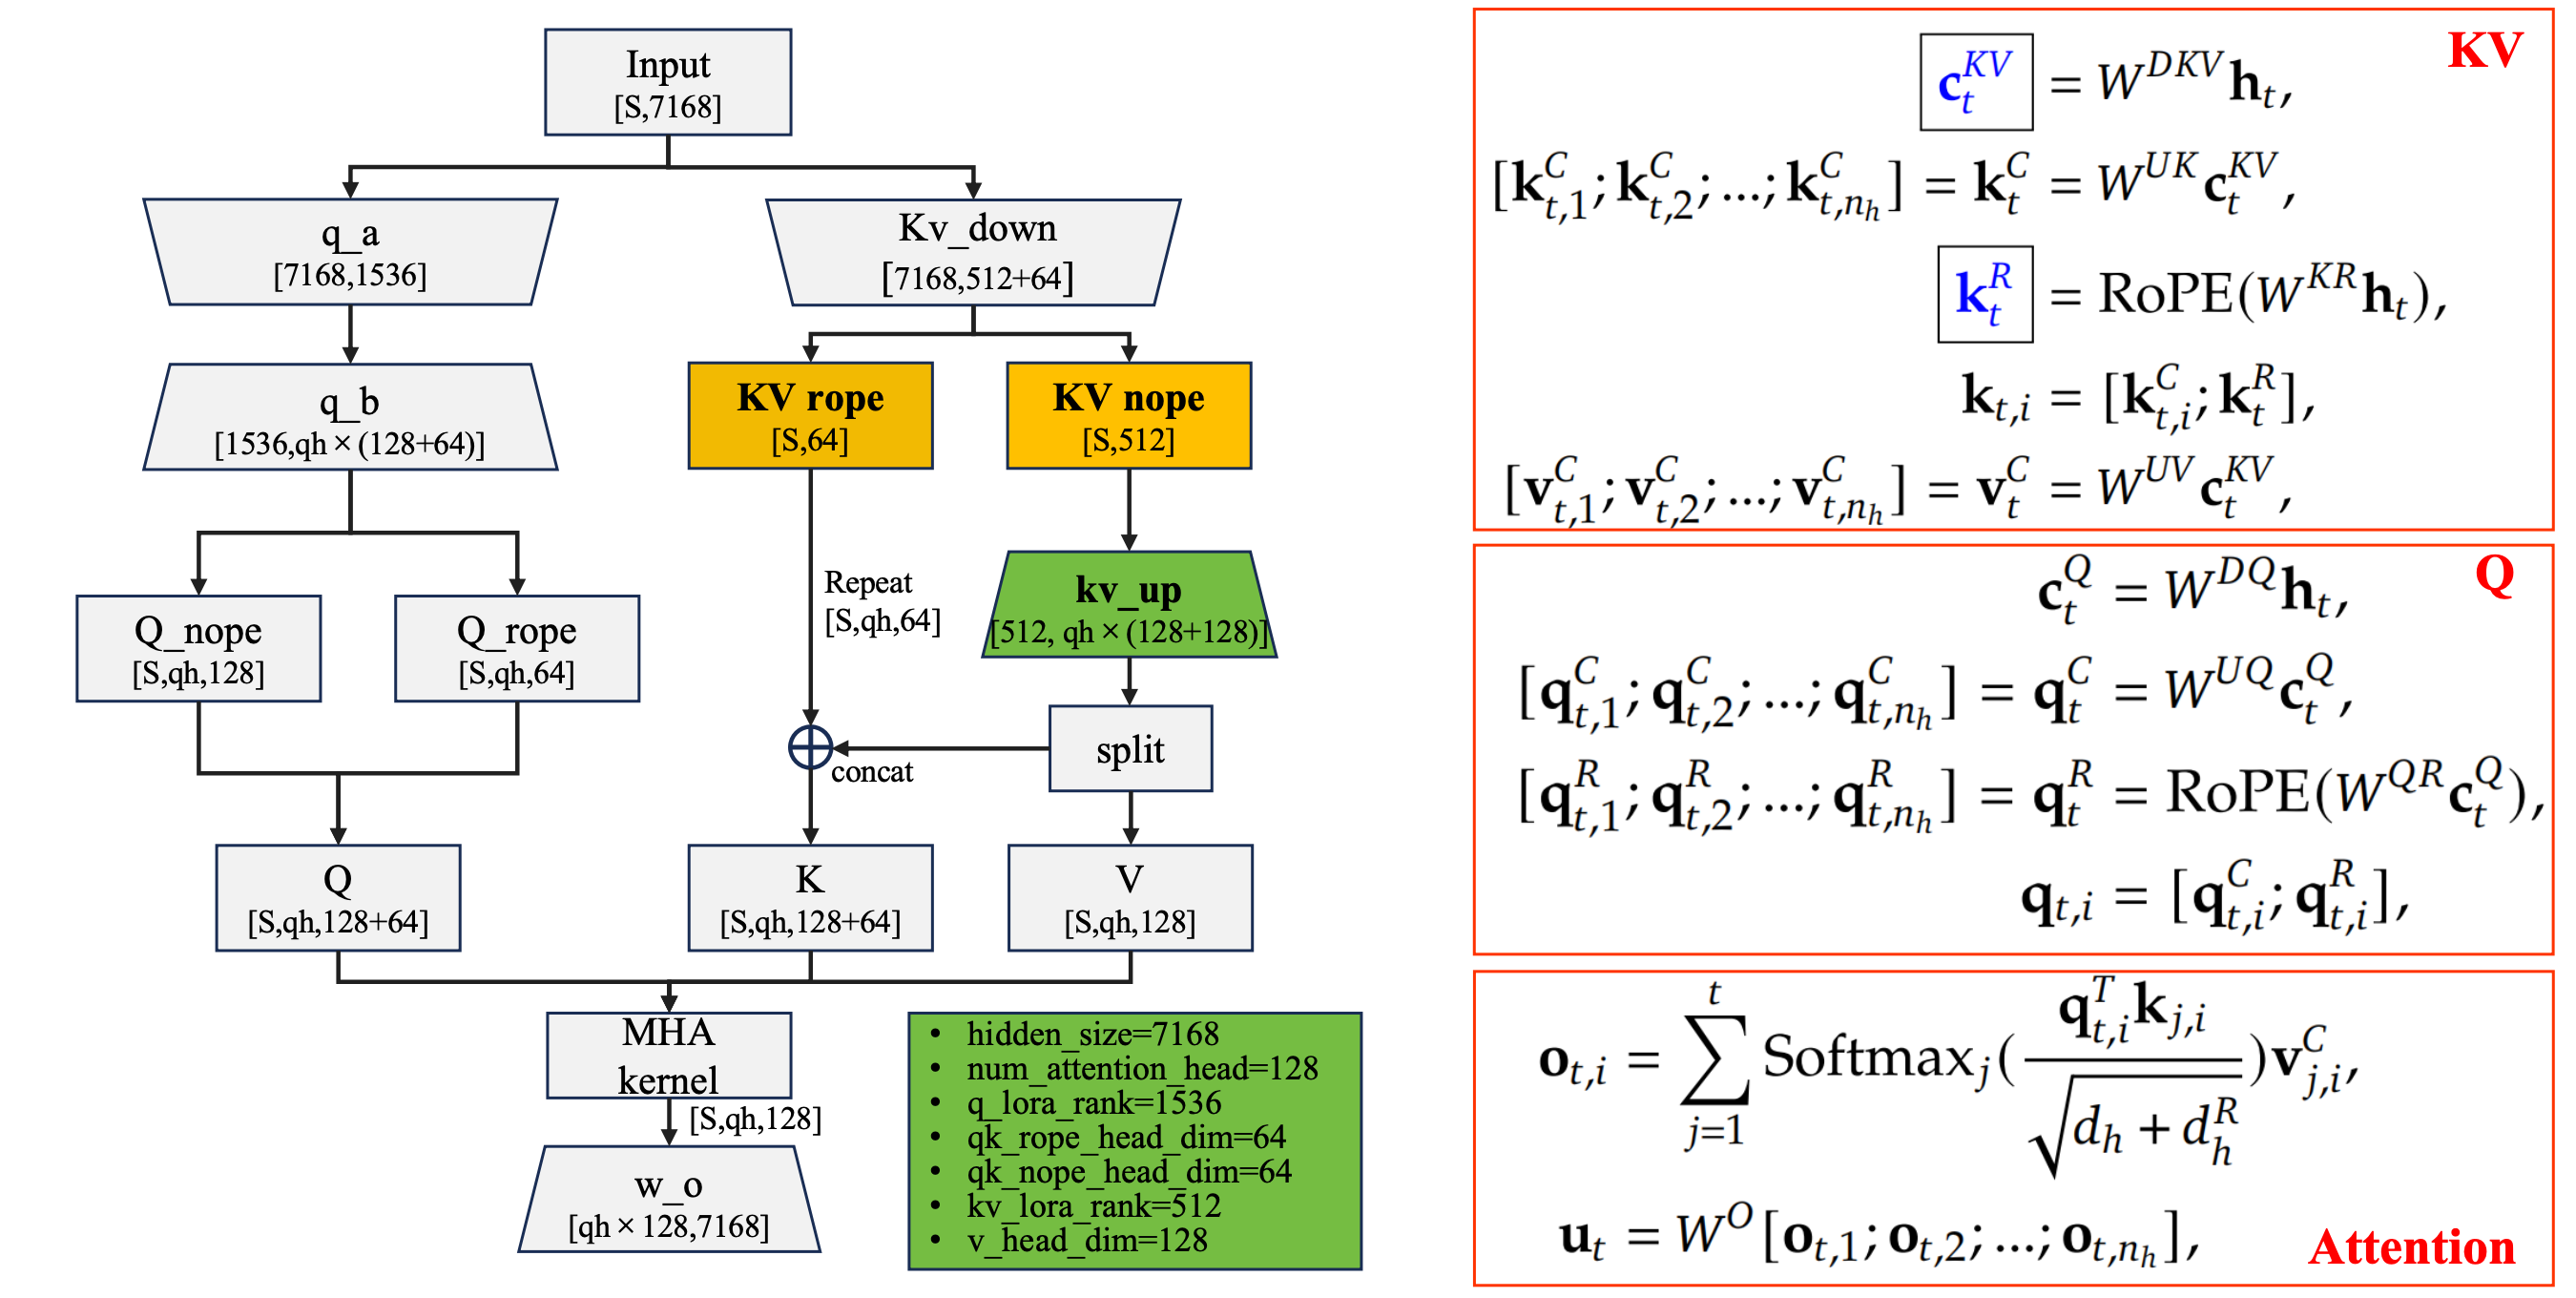

In [8]:
from IPython.display import Image, display

# 替换为你的桌面路径（关键！）
# Windows 示例: 'C:/Users/你的用户名/Desktop/MLA-Prefill.png'
# macOS/Linux 示例: '/Users/你的用户名/Desktop/MLA-Prefill.png'
image_path = r'C:/Users/1/Desktop/MLA-Prefill.png'  # ← 修改这里！

display(Image(filename=image_path))

# 手写MLA  Prefill阶段

In [3]:
@dataclass
class Config:
    hidden_size:int
    n_heads:int
    max_pos:int
    rope_theta:float
    rope_head_dim:int
    q_lora_rank:int
    kv_lora_rank:int
    head_dim:int
    dropout:float

class MLA(nn.Module):
    ''''MLA prefill 阶段核心实现
    '''
    def __init__(self,config):
        super().__init__()

        self.dropout = config.dropout
        self.hidden_size = config.hidden_size
        self.n_heads = config.n_heads
        self.max_pos = config.max_pos
        self.rope_theta = config.rope_theta

        # 在deepseek v3中，hidden_size为 7168
        # 压缩后的kv d_c=512, 压缩比例 1/14
        # q的压缩为1536，压缩比例为 1/4.7
        # rope的维度是 64

        #对应 q（query）的压缩向量
        self.q_lora_rank = config.q_lora_rank

        #对应q（query) 和 k（key) 进行rope的维度
        self.rope_head_dim = config.rope_head_dim

        #对应key,value的压缩向量
        self.kv_lora_rank = config.kv_lora_rank

        #对应每一个head的维度 每一个头的维度
        self.head_dim = config.head_dim

        #对应Q,K做attention的维度 nope_dim + rope_dim
        self.q_head_dim = config.head_dim + config.rope_head_dim

        #Q的降维和升维
        self.q_down_proj = nn.Linear(
            self.hidden_size,
            self.q_lora_rank,
            bias=False
        )

        self.q_up_proj = nn.Linear(
            self.q_lora_rank,
            self.n_heads*self.q_head_dim,
            bias=False
        )
        #KV的降维和升维
        self.kv_down_proj = nn.Linear(
            self.hidden_size,
            self.kv_lora_rank+self.rope_head_dim,
            bias=False
        )

        self.kv_up_proj = nn.Linear(
            self.kv_lora_rank,
            self.n_heads * (self.head_dim + self.head_dim), # 最终还需要做切分，一部分是K的，一部分是V的
            bias=False
        )
        # 最终输出映射层 O
        self.o_proj = nn.Linear(
            self.n_heads * self.head_dim,
            self.hidden_size,
            bias=False
        )

        # 初始化 ROPE 的类
        self.rotary_emb = ROPE(
            self.rope_head_dim,
            self.max_pos,
            self.rope_theta
        )
        #            hidden_states为输入
    def forward(self,hidden_states,attention_mask=None,position_ids=None):
        """
        MLA Prefill阶段的核心实现
        """
        bsz,q_len,_ = hidden_states.size()

        #第一步  Q的降维升维映射，以及nope和rope的切分
        q = self.q_up_proj(self.q_down_proj(hidden_states))
        #把self.n_heads*self.q_head_dim拆开
        q = q.view(bsz,q_len,self.n_heads,self.q_head_dim).transpose(1,2)
        q_nope,q_pe = torch.split(q,
            [self.head_dim,self.rope_head_dim],
            dim=-1
        )

        #第二步  KV的降维升维映射，以及nope和rope的切分
        compressed_kv = self.kv_down_proj(hidden_states)
        compressed_kv, k_pe = torch.split(compressed_kv,
            [self.kv_lora_rank, self.rope_head_dim],
            dim=-1
        )
        k_pe = k_pe.view(bsz,q_len,1,self.rope_head_dim).transpose(1,2)#最开始切分的时候，也就是升维之前   都是单头的，记得最后输出时转换回来
        kv = self.kv_up_proj(compressed_kv)
        kv = kv.view(bsz,q_len,self.n_heads,self.head_dim + self.head_dim).transpose(1,2)

        k_nope,value_states = torch.split(kv,
            [self.head_dim,self.head_dim],
            dim=-1
        )

        #第三步 给 q_pe和 k_pe 分别做ROPE
        kv_seq_len = value_states.shape[-2]#ROPE类需要传入seq_len，所以要提前拿到

        cos, sin =  self.rotary_emb(value_states,seq_len = kv_seq_len)#在ROPE类中，只会调用value_states的dtype
        q_pe = apply_rotary_pos_emb(q_pe,cos,sin,position_ids)
        k_pe = apply_rotary_pos_emb(k_pe, cos, sin, position_ids)


        #最终输出的Q,K,V的维度为  [batch_size,n_heads,seq_len,head_dim]
        #Q , K的维度为 self.head_dim + self.rope_head_dim
        # V的维度为 self.head_dim

        #第四步  组合 query和 key ROPE 的部分和 NOPE 的部分
        query_states = torch.empty(
            bsz,self.n_heads,q_len,self.q_head_dim,
            device = k_pe.device
        )
        query_states[:, :, :, :self.head_dim] = q_nope
        query_states[:, :, :, self.head_dim:] = q_pe

        key_states = torch.empty(
            bsz, self.n_heads, q_len, self.q_head_dim,
            device=k_pe.device
        )
        key_states[:, :, :, :self.head_dim] = k_nope
        key_states[:, :, :, self.head_dim:] = k_pe

        #第五步 计算注意力得分
        attn_weights = torch.matmul(query_states,key_states.transpose(2,3))
        attn_weights = attn_weights / math.sqrt(self.q_head_dim)

        #计算casual mask
        if attention_mask is not None:
            attn_weights = torch.masked_fill(
                attn_weights,
                attention_mask,
                float("-inf")
            )


        #第六步 计算softmax 和dropout
        attn_weights = F.softmax(
            attn_weights, dim=-1, dtype=torch.float32
        ).to(query_states.dtype)
        attn_weights = F.dropout(attn_weights, p=self.dropout, training=self.training)


        #第七步  计算注意力输出
        attn_output = torch.matmul(attn_weights,value_states)
        attn_output = attn_output.transpose(1, 2).reshape(bsz, q_len, -1)
        attn_output = self.o_proj(attn_output)

        return attn_output, attn_weights, compressed_kv, k_pe

In [4]:
config = Config(
    hidden_size=7168,
    n_heads=128,
    max_pos=1024,
    rope_theta=50000,
    rope_head_dim=64,
    q_lora_rank=1536,
    kv_lora_rank=512,
    head_dim=128,
    dropout=0.1)
print(config)


Config(hidden_size=7168, n_heads=128, max_pos=1024, rope_theta=50000, rope_head_dim=64, q_lora_rank=1536, kv_lora_rank=512, head_dim=128, dropout=0.1)


In [5]:
# 定义参数
batch_size = 2
seq_len = 10
x = torch.randn(batch_size, seq_len, config.hidden_size)
mla = MLA(config)

In [6]:
# 构造mask
mask = torch.full((1, 1, seq_len, seq_len), True)
mask = torch.triu(mask, diagonal=1)
print(mask)

tensor([[[[False,  True,  True,  True,  True,  True,  True,  True,  True,  True],
          [False, False,  True,  True,  True,  True,  True,  True,  True,  True],
          [False, False, False,  True,  True,  True,  True,  True,  True,  True],
          [False, False, False, False,  True,  True,  True,  True,  True,  True],
          [False, False, False, False, False,  True,  True,  True,  True,  True],
          [False, False, False, False, False, False,  True,  True,  True,  True],
          [False, False, False, False, False, False, False,  True,  True,  True],
          [False, False, False, False, False, False, False, False,  True,  True],
          [False, False, False, False, False, False, False, False, False,  True],
          [False, False, False, False, False, False, False, False, False, False]]]])


In [7]:
position_ids = torch.arange(config.max_pos).unsqueeze(0).expand(x.size(0), -1)
print(position_ids)

tensor([[   0,    1,    2,  ..., 1021, 1022, 1023],
        [   0,    1,    2,  ..., 1021, 1022, 1023]])


In [8]:
attn_output, attn_weights, compressed_kv, k_pe = mla(x, mask, position_ids[:, :seq_len])
print("attn_output shape: ", attn_output.shape) # [batch, seq_len, hidden_size]
print("attn_weights shape: ", attn_weights.shape) #[batch, n_heads, seq_len, seq_len]
print("compressed_kv shape: ", compressed_kv.shape) # [batch, seq_len, kv_lora_rank]
print("k_pe shape: ", k_pe.shape) # [batch, seq_len, rope_head_dim]
print("attention output: ", attn_output)

attn_output shape:  torch.Size([2, 10, 7168])
attn_weights shape:  torch.Size([2, 128, 10, 10])
compressed_kv shape:  torch.Size([2, 10, 512])
k_pe shape:  torch.Size([2, 1, 10, 64])
attention output:  tensor([[[-0.1861, -0.1798,  0.1654,  ..., -0.0257,  0.0322, -0.4484],
         [-0.0579, -0.3356,  0.0715,  ..., -0.0904, -0.0902, -0.1677],
         [-0.1024, -0.2197, -0.0727,  ...,  0.0313, -0.0032, -0.0498],
         ...,
         [-0.0770, -0.0398,  0.0284,  ..., -0.0851,  0.0969, -0.0160],
         [-0.0362,  0.0089,  0.0104,  ..., -0.0753,  0.0249,  0.0295],
         [ 0.0011,  0.0237,  0.0690,  ..., -0.0739, -0.0185,  0.0137]],

        [[-0.1365, -0.1104,  0.3093,  ..., -0.1174,  0.1594,  0.3158],
         [-0.0400, -0.1110,  0.1497,  ...,  0.0354,  0.0969,  0.1779],
         [ 0.0289,  0.0047,  0.0355,  ..., -0.0470,  0.0485,  0.0708],
         ...,
         [ 0.0499, -0.0178,  0.0576,  ..., -0.0330,  0.0092, -0.0406],
         [ 0.0717, -0.0050, -0.0100,  ..., -0.0328, -0.008